# python for stock trading


##### this ducument explains how to import stock's data from YAHOO, choose the best market to invest in, calculate you portfolio, and other intersting things.

In [2]:
import yfinance
import mplfinance as mpf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px
import datetime as dt
import os

pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 1000

sns.set()

### Library Imports
In this section, we import libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`, `plotly`, `mplfinance`), and financial data retrieval (`yfinance`). We also import `scipy.stats` and `statsmodels` for performing regression and statistical analysis.


# downloading Data From YAHOO!

In [3]:
stocknames = ['AAPL', 'MSFT', 'TSLA', 'GC=F', 'SPY']
startdate = '2025-01-01'
enddate = dt.datetime.now().date()
interval = '1d'

In [4]:
for stock in stocknames:
    df = yfinance.download(stock, start=startdate, end=enddate, interval=interval, auto_adjust=False, actions=False)
    df.reset_index(inplace=True)
    df.to_csv('{}.csv'.format(stock), index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Data Retrieval
We use the `yfinance` API to download historical market data. For each ticker in our list, we fetch the data and save it as a CSV file for local access. This ensures we have a persistent copy of the data.


In [5]:
def appnding(cols = [], startdate='', enddate=''):
    global df
    dates = pd.date_range(start=startdate, end=enddate)
    df = pd.DataFrame(index=dates)
    
    for stock in stocknames:
        df_symbols = pd.read_csv('{}.csv'.format(stock), index_col='Date', parse_dates=True, usecols=cols, na_values=['NAN'])
        df_symbols = df_symbols.rename(columns={'Adj Close': stock})
        df = df.join(df_symbols)
    
    df = df.dropna()
    return df

In [6]:
appnding(['Date', 'Adj Close'], startdate, enddate)
df.index.names = ['Date']
df = df.rename(columns={'GC=F':'gold', 'AAPL' : 'aapl', 'MSFT' : 'msft', 'TSLA' : 'tsla', 'SPY':'spy'})
df.head()

,aapl,msft,tsla,gold,spy
Date,,,,,
2025-01-02,242.52517700195312,414.568603515625,379.2799987792969,2658.89990234375,576.2802734375
2025-01-03,242.03781127929688,419.2928771972656,410.44000244140625,2645.0,583.4857788085938
2025-01-06,243.66891479492188,423.749755859375,411.04998779296875,2638.39990234375,586.8470458984375
2025-01-07,240.8940887451172,418.322265625,394.3599853515625,2656.699951171875,580.2133178710938
2025-01-08,241.38140869140625,420.49127197265625,394.94000244140625,2664.5,581.06103515625


### Data Consolidation
The `appnding` function aligns the 'Adj Close' prices for all tickers into a single DataFrame based on a common date index. Renaming columns to lowercase and descriptive names (e.g., 'gold' for 'GC=F') makes the code cleaner and more intuitive.


## GLOBAL STATISTICS

In [7]:
df = df.astype(float)
df_desc = df.describe().T
df_desc = df_desc[['count', 'mean', 'std', '50%', 'max']]
df_desc

,count,mean,std,50%,max
aapl,339.00,239.88,27.30,242.53,293.32
msft,339.00,449.20,51.28,453.48,539.83
tsla,339.00,368.82,64.83,379.28,489.88
gold,339.00,"3,808.58",740.45,"3,636.90","5,318.40"
spy,339.00,633.01,52.71,643.37,739.30


### Summary Statistics
Descriptive statistics provide a quick overview of the price levels. The `mean` shows the average price, while the `std` (standard deviation) indicates the historical volatility of the asset's price.


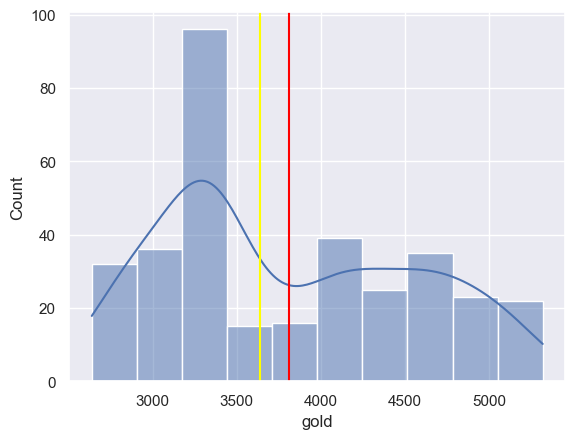

In [8]:
sns.histplot(data=df, x='gold', kde=True)
plt.axvline(df.gold.mean(), color="red")
plt.axvline(df.gold.median(), color="yellow")

In [9]:
px.line(data_frame=df, title='tickers adj. close price')

### Price Visualization
Visualizing the raw adjusted close prices allows us to see the absolute price trends. However, because different stocks have different price ranges, it can be difficult to compare their relative performance at a glance.


### normalizing

In [10]:
norm = df / df.iloc[0,:]
fig = px.line(norm)
fig.update_layout(title='stack movement observation by normalizing adj close prices , (daily cumulative return)',
                   xaxis_title='Date', 
                   yaxis_title='Normalized price')
fig.show()

### Normalization and Cumulative Returns
By dividing every price by the first price in the series, we 'normalize' the data so all assets start at 1.0. This makes it easy to compare the percentage growth of different stocks (e.g., Apple vs. Tesla) over the same period regardless of their starting price.


<Axes: xlabel='tsla', ylabel='Count'>

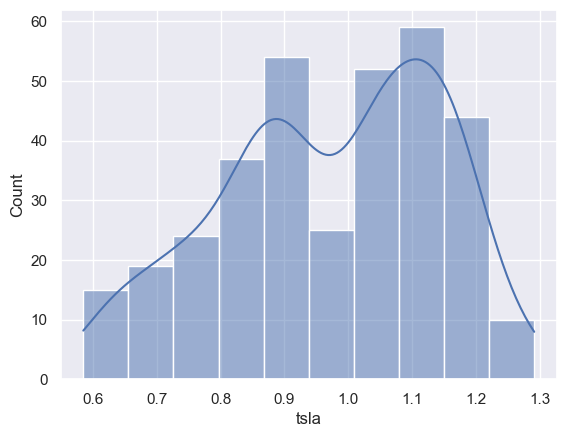

In [11]:
sns.histplot(data=norm, x=norm['tsla'], kde=True)

### Rolling Statistics

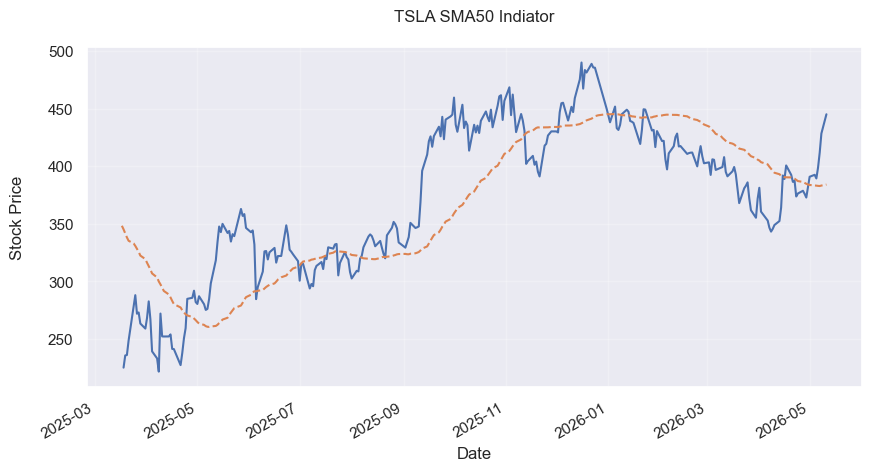

In [12]:
rollingmean = df.tsla.rolling(50).mean()
rollingstd = df.tsla.rolling(50).std() *2
fig, ax = plt.subplots(figsize=(10,5))
df.iloc[50:]['tsla'].plot(ax=ax)
ax.set_title('TSLA SMA50 Indiator\n')
ax.set_xlabel('Data')
ax.set_ylabel('Stock Price\n')
rollingmean.plot(ax=ax, linestyle='--')
plt.grid(alpha=0.25)

### Simple Moving Average (SMA)
The 50-day SMA is a trend-following indicator. It smooths out short-term price noise to reveal the underlying long-term direction of the stock.


### Bollinger Bands

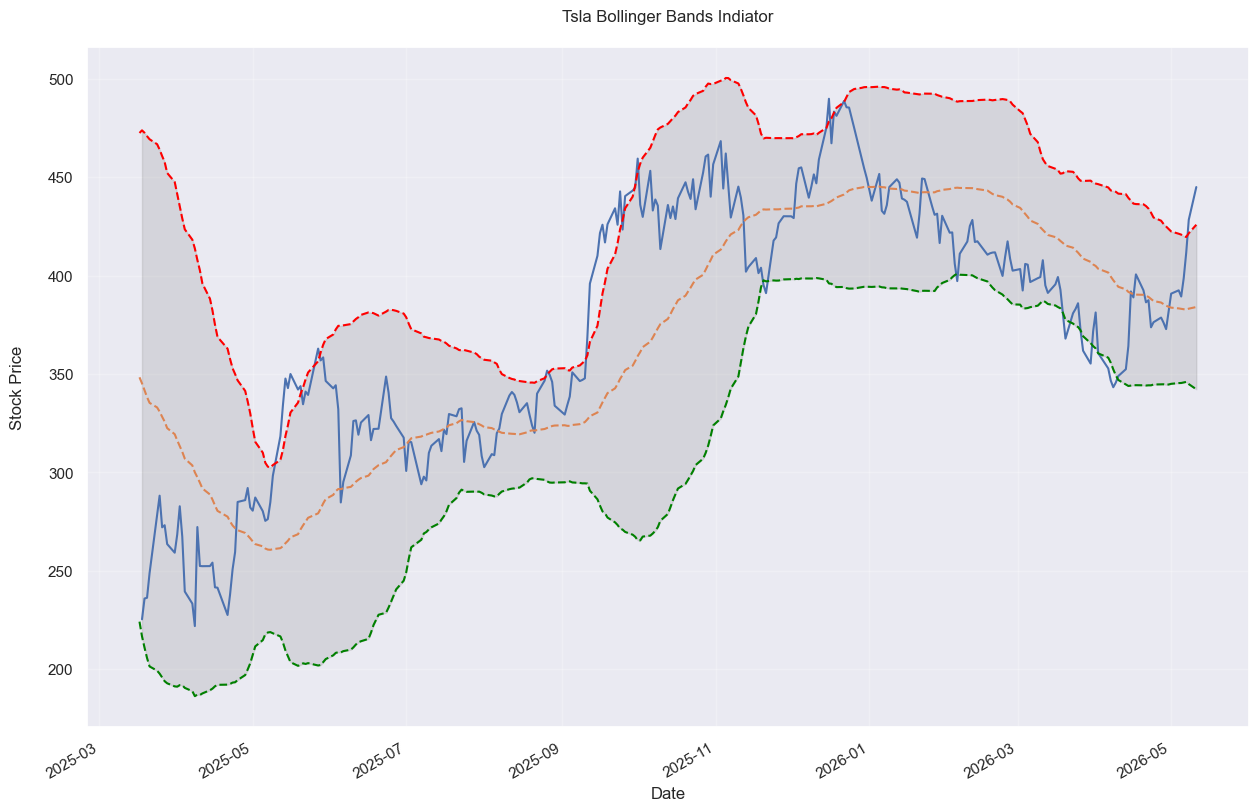

In [13]:
rollingmean = df.tsla.rolling(50).mean()
rollingstd = df.tsla.rolling(50).std() *2
fig, ax = plt.subplots(figsize=(15,10))
df.iloc[50:]['tsla'].plot(ax=ax)
ax.set_title('Tsla Bollinger Bands Indiator\n')
ax.set_xlabel('Data')
ax.set_ylabel('Stock Price\n')
rollingmean.plot(ax=ax, linestyle='--')
upper_band = rollingmean + rollingstd
lower_band = rollingmean - rollingstd
upper_band.plot(ax=ax, linestyle='--', label='Upper Band (+2 STD)', color='red')
lower_band.plot(ax=ax, linestyle='--', label='Lower Band (-2 STD)', color='green')
ax.fill_between(df.index[50:], upper_band.iloc[50:], lower_band.iloc[50:], alpha=0.2, color='gray')
plt.grid(alpha=0.25)

### Bollinger Bands
Bollinger Bands consist of an SMA and two lines plotted at standard deviation levels above and below it. They expand and contract based on volatility. Prices near the upper band may indicate an 'overbought' condition, while prices near the lower band may indicate 'oversold'.


### - Matrics

-daily Returns
-commuulative Returns
-sharpe Ratio

In [14]:
daily_returns = df.pct_change()
daily_returns.iloc[0,:] = 0
daily_returns.head()

,aapl,msft,tsla,gold,spy
Date,,,,,
2025-01-02,0.00,0.00,0.00,0.00,0.00
2025-01-03,-0.00,0.01,0.08,-0.01,0.01
2025-01-06,0.01,0.01,0.00,-0.00,0.01
2025-01-07,-0.01,-0.01,-0.04,0.01,-0.01
2025-01-08,0.00,0.01,0.00,0.00,0.00


### Daily Returns
Daily returns represent the percentage gain or loss from one day to the next. In finance, we typically analyze returns rather than prices because returns are stationary and comparable across different assets.


In [15]:
daily_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
aapl,339.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.15
msft,339.00,0.00,0.02,-0.10,-0.01,0.00,0.01,0.10
tsla,339.00,0.00,0.04,-0.15,-0.02,0.00,0.02,0.23
gold,339.00,0.00,0.02,-0.11,-0.01,0.00,0.01,0.06
spy,339.00,0.00,0.01,-0.06,-0.00,0.00,0.01,0.11


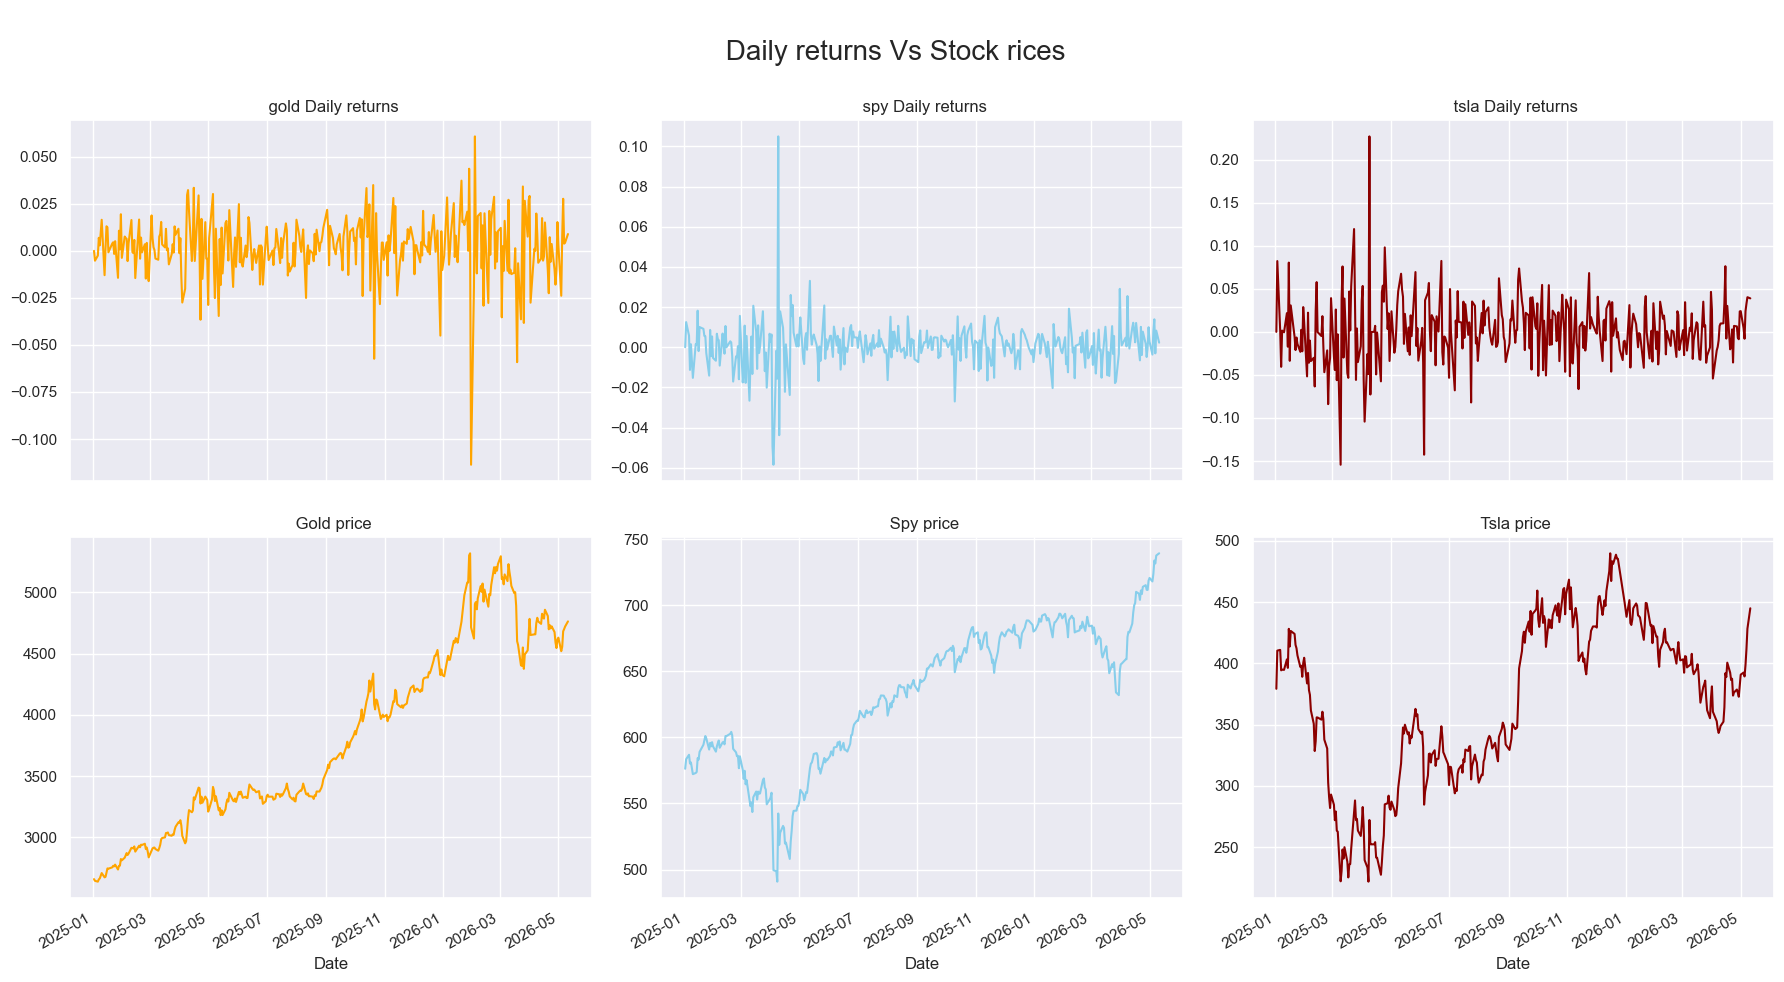

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

daily_returns.gold.plot(ax=ax[0][0], color='orange')
ax[0][0].set_title('\n gold Daily returns')

daily_returns.spy.plot(ax=ax[0][1], color='skyblue')
ax[0][1].set_title('\n spy Daily returns')

daily_returns.tsla.plot(ax=ax[0][2], color='darkred')
ax[0][2].set_title('\n tsla Daily returns')

df.gold.plot(kind='line', ax=ax[1][0], color='orange')
ax[1][0].set_title('\n Gold price')

df.spy.plot(kind='line', ax=ax[1][1], color='skyblue')
ax[1][1].set_title('\n Spy price')

df.tsla.plot(kind='line', ax=ax[1][2], color='darkred')
ax[1][2].set_title('\n Tsla price')
fig.suptitle('\n Daily returns Vs Stock rices', fontsize=20)
plt.tight_layout()

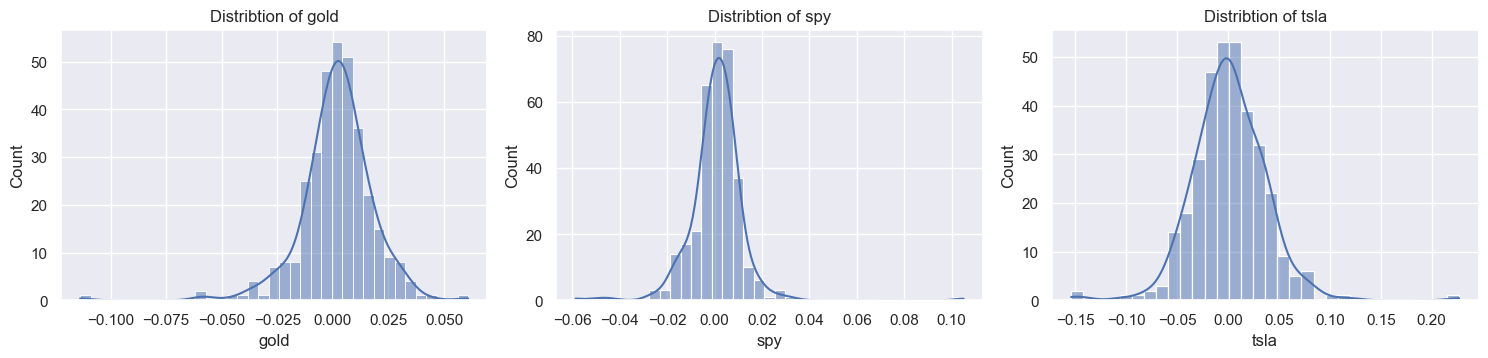

In [17]:
plt.figure(figsize=(20, 10))
for e, i in enumerate(daily_returns[['gold', 'spy', 'tsla']]):
    plt.subplot(3, 4, e+1)
    sns.histplot(daily_returns[i], kde=True)
    plt.title("Distribtion of " + i)
    plt.tight_layout()




### Distribution of Returns
We use histograms and Kernel Density Estimates (KDE) to visualize how returns are distributed. Most stock returns exhibit 'fat tails' (high kurtosis), meaning extreme price moves happen more often than a normal distribution would predict.


### cumulative returns ratio: is the profit/lose ratio of the stock on practicular period 

In [18]:
stocknames = df.columns

for stock in stocknames:
    print("cumulative return of {} is: {} %".format(stock, round(((df.iloc[-1][stock] / df.iloc[0][stock]) - 1) * 100, 2)))

cumulative return of aapl is: 20.68 %
cumulative return of msft is: -0.46 %
cumulative return of tsla is: 17.33 %
cumulative return of gold is: 79.12 %
cumulative return of spy is: 28.29 %


### Cumulative Performance
Cumulative return calculates the total profit or loss percentage since the start of the period. It helps investors understand the total 'buy and hold' outcome.


In [19]:
daily_returns.describe().T

,count,mean,std,min,25%,50%,75%,max
aapl,339.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.15
msft,339.00,0.00,0.02,-0.10,-0.01,0.00,0.01,0.10
tsla,339.00,0.00,0.04,-0.15,-0.02,0.00,0.02,0.23
gold,339.00,0.00,0.02,-0.11,-0.01,0.00,0.01,0.06
spy,339.00,0.00,0.01,-0.06,-0.00,0.00,0.01,0.11


<Axes: xlabel='Date'>

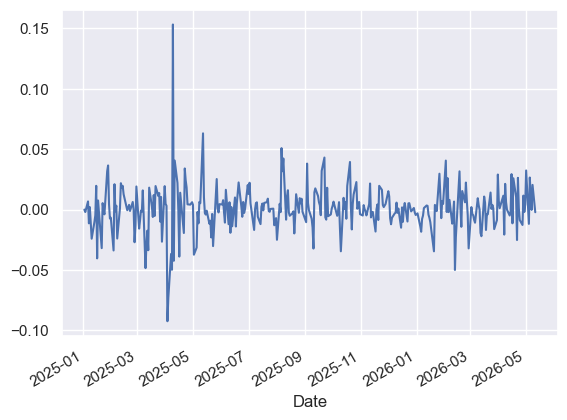

In [20]:
daily_returns.aapl.plot()

In [21]:
((daily_returns.gold[daily_returns.gold >= 0].sum()) + (daily_returns.gold[daily_returns.gold < 0].sum())) * 100

np.float64(62.81330034172912)

#### mean
### STD
### Kurtosis
### (volatiliy)risk/return

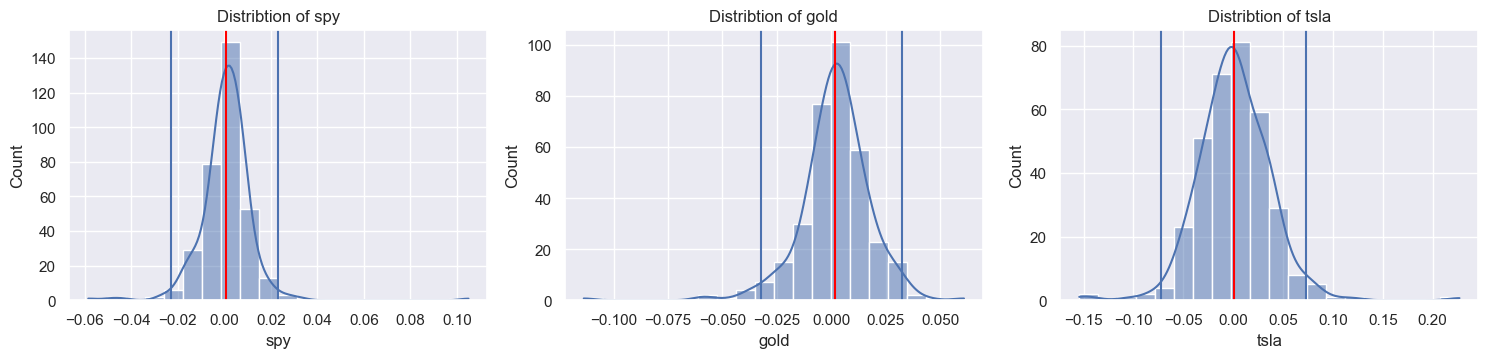

In [22]:
plt.figure(figsize=(20, 10))
for e, i in enumerate(daily_returns[['spy', 'gold', 'tsla']]):
    plt.subplot(3, 4, e+1)
    sns.histplot(daily_returns[i], kde=True, bins=20)
    plt.axvline(daily_returns[i].mean(), color="red")
    plt.axvline(daily_returns[i].std() * 2)
    plt.axvline(-daily_returns[i].std() * 2)
    plt.title("Distribtion of " + i)
    plt.tight_layout()


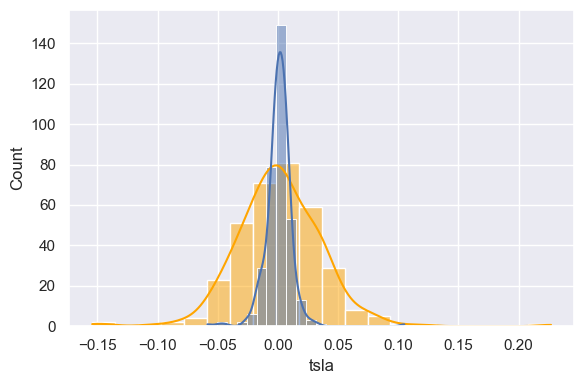

In [23]:
plt.figure(figsize=(6, 4))
sns.histplot(daily_returns.tsla, kde=True, bins=20, color="orange")
sns.histplot(daily_returns.spy, kde=True, bins=20)
plt.tight_layout()

In [24]:
print(f'the mean of Spy dr = {daily_returns.spy.mean() * 100}')
print(f'the std of Spy dr = {daily_returns.spy.std()}')
print(f'the kurtosis of Spy dr = {daily_returns.spy.kurtosis()}')

the mean of Spy dr = 0.0799757582925443
the std of Spy dr = 0.011443243672153908
the kurtosis of Spy dr = 23.100185555437804


In [25]:
print(f'the mean of tsla dr = {daily_returns.tsla.mean() * 100}')
print(f'the std of tsla dr = {daily_returns.tsla.std()}')
print(f'the kurtosis of tsla dr = {daily_returns.tsla.kurtosis()}')

the mean of tsla dr = 0.11266988062482869
the std of tsla dr = 0.03637346162394674
the kurtosis of tsla dr = 5.382642098207861


### Risk and Volatility Metrics
By calculating the mean, standard deviation, and kurtosis of daily returns, we quantify the risk/reward profile. Higher standard deviation means higher volatility (risk), while higher kurtosis indicates a higher probability of extreme price spikes or drops.


## linear Regression model

[[1.         0.72075462]
 [0.72075462 1.        ]]


<Axes: >

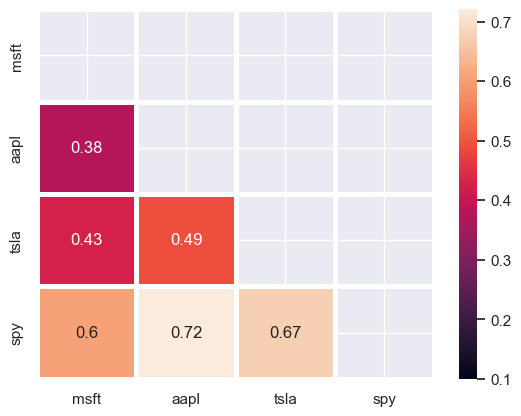

In [26]:
daily_returns = daily_returns[['msft', 'aapl', 'tsla', 'spy']]
print(np.corrcoef(daily_returns.spy, daily_returns.aapl))
mask = np.zeros_like(daily_returns.corr())
mask[np.triu_indices_from(mask)] = True
mask
sns.heatmap(daily_returns.corr(), annot=True, vmin=0.1, mask=mask, linewidths=2.5)

<Axes: xlabel='tsla', ylabel='spy'>

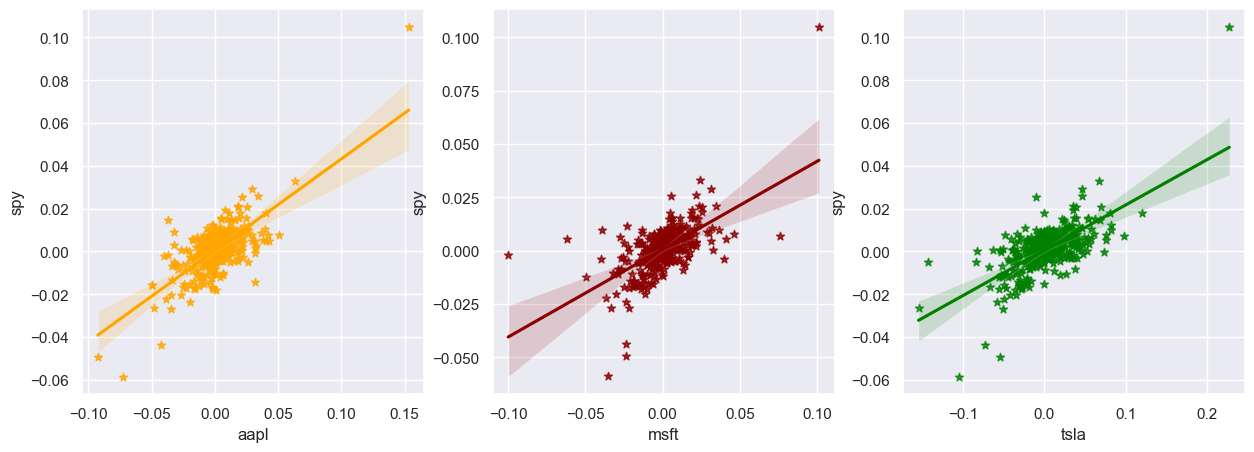

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.regplot(data=daily_returns, x=daily_returns.aapl, y=daily_returns.spy, scatter=True, marker="*", ax=ax[0], color="orange")
sns.regplot(data=daily_returns, x=daily_returns.msft, y=daily_returns.spy, scatter=True, marker="*", ax=ax[1], color="darkred")
sns.regplot(data=daily_returns, x=daily_returns.tsla, y=daily_returns.spy, scatter=True, marker="*", ax=ax[2], color="green")

### Regression and Correlation
Correlation matrices and regression plots (scatter plots with a line of best fit) show how stocks move in relation to one another and to the market (SPY). A positive correlation indicates that the assets tend to move in the same direction.


<Axes: xlabel='msft', ylabel='aapl'>

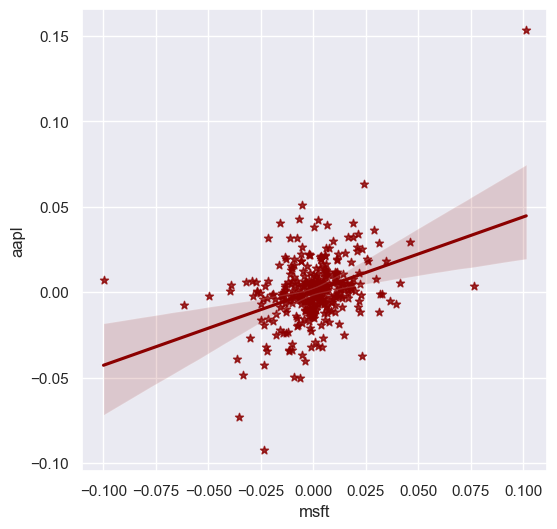

In [28]:
plt.figure(figsize=(6, 6))
sns.regplot(data=daily_returns, x=daily_returns.msft, y=daily_returns.aapl, scatter=True, marker="*", color="darkred")


In [29]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.spy, ml[['intercept', 'aapl']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     364.3
Date:                Tue, 12 May 2026   Prob (F-statistic):           1.40e-55
Time:                        00:20:10   Log-Likelihood:                 1159.2
No. Observations:                 339   AIC:                            -2314.
Df Residuals:                     337   BIC:                            -2307.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0005      0.000      1.121      0.263      -0.000       0.001
aapl           0.4278      0.022     19.088      0.000       0.384       0.472
==============================================================================
Omnibus:                       24.196   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               85.315
Skew:                           0.083   Prob(JB):                     2.98e-19
Kurtosis:                       5.452   Cond. No.                         51.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.spy, ml[['intercept', 'msft']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     193.5
Date:                Tue, 12 May 2026   Prob (F-statistic):           4.44e-35
Time:                        00:20:10   Log-Likelihood:                 1111.8
No. Observations:                 339   AIC:                            -2220.
Df Residuals:                     337   BIC:                            -2212.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0007      0.000      1.507      0.133      -0.000       0.002
msft           0.4117      0.030     13.911      0.000       0.353       0.470
==============================================================================
Omnibus:                       85.619   Durbin-Watson:                   2.229
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1361.252
Skew:                           0.536   Prob(JB):                    2.56e-296
Kurtosis:                      12.758   Cond. No.                         59.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Capital Asset Pricing Model (CAPM) - Beta
The OLS (Ordinary Least Squares) regression output gives us the 'Beta' coefficient. A Beta of 1.0 means the stock moves with the market. A Beta > 1.0 (like Tesla often is) means the stock is more volatile than the market, while a Beta < 1.0 means it is less sensitive to market swings.


In [31]:
ml = daily_returns.copy()
ml['intercept'] = 1
lm = sm.OLS(ml.spy, ml[['intercept', 'tsla']])
res = lm.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     281.3
Date:                Tue, 12 May 2026   Prob (F-statistic):           2.47e-46
Time:                        00:20:10   Log-Likelihood:                 1137.8
No. Observations:                 339   AIC:                            -2272.
Df Residuals:                     337   BIC:                            -2264.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0006      0.000      1.220      0.223      -0.000       0.001
tsla           0.2122      0.013     16.773      0.000       0.187       0.237
==============================================================================
Omnibus:                       69.325   Durbin-Watson:                   2.053
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              786.736
Skew:                           0.421   Prob(JB):                    1.45e-171
Kurtosis:                      10.415   Cond. No.                         27.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [32]:
slop , intercept, coef, p, std_err = stats.linregress(daily_returns.aapl, daily_returns.spy)
print(f"AAPL/SPY\nbeta slop = {slop}\nalpha (intercept) = {intercept}\nR-squared = {coef**2}\npvalue = {p}")
print("===============================================================")
slop , intercept, coef, p, std_err = stats.linregress(daily_returns.msft, daily_returns.spy)
print(f"MSFT/SPY\nbeta slop = {slop}\nalpha (intercept) = {intercept}\nR-squared = {coef**2}\npvalue = {p}")
print("===============================================================")
slop , intercept, coef, p, std_err = stats.linregress(daily_returns.tsla, daily_returns.spy)
print(f"TSLA/SPY\nbeta slop = {slop}\nalpha (intercept) = {intercept}\nR-squared = {coef**2}\npvalue = {p}")

AAPL/SPY
beta slop = 0.427790660652864
alpha (intercept) = 0.0004840440128084109
R-squared = 0.5194872252503241
pvalue = 1.3999757428425916e-55
MSFT/SPY
beta slop = 0.411657623831328
alpha (intercept) = 0.0007475026318529724
R-squared = 0.3647808369434564
pvalue = 4.4382210931625504e-35
TSLA/SPY
beta slop = 0.21220666174175304
alpha (intercept) = 0.0005606645904630759
R-squared = 0.45497654021155826
pvalue = 2.4731336598585622e-46
